In [23]:
import pandas as pd
file_path = "C:/Users/Sharm/Downloads/sample_candidates.csv"  
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
for col in df.columns:
    if df[col].dtype == "object":  # Categorical columns
        df[col].fillna("Unknown", inplace=True)
    else: 
        df[col].fillna(df[col].mean(), inplace=True)
df.drop_duplicates(inplace=True)
cleaned_file_path = "C:/Users/Sharm/Downloads/cleaned_candidates.csv"
df.to_csv(cleaned_file_path, index=False)
print(f"Cleaned dataset saved at: {cleaned_file_path}")
print("First 5 rows of cleaned data:\n", df.head())


Cleaned dataset saved at: C:/Users/Sharm/Downloads/cleaned_candidates.csv
First 5 rows of cleaned data:
             name  experience                            skills  \
0       John Doe    5.000000     Python, SQL, Machine Learning   
1     Jane Smith    3.000000                 Java, Spring Boot   
2  Emily Johnson    7.000000  C++, Data Structures, Algorithms   
3  Michael Brown    4.777778                 JavaScript, React   
4    Sarah Davis    2.000000                    Python, Pandas   

   expected_salary       location                   email  
0            80000       New York    john.doe@example.com  
1            65000  San Francisco  jane.smith@example.com  
2            90000        Chicago     emily.j@example.com  
3            70000         Austin   michael.b@example.com  
4            60000        Seattle     sarah.d@example.com  


C:\Users\Sharm\AppData\Local\Temp\ipykernel_27784\1415943652.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)
C:\Users\Sharm\AppData\Local\Temp\ipykernel_27784\1415943652.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

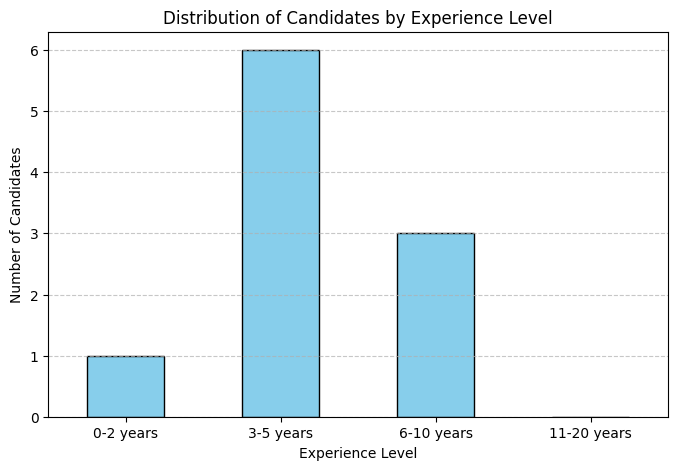

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = "C:/Users/Sharm/Downloads/candidate_list.csv"
df = pd.read_csv(file_path)
bins = [0, 2, 5, 10, 20]  # Experience ranges (0-2, 3-5, 6-10, 11-20 years)
labels = ["0-2 years", "3-5 years", "6-10 years", "11-20 years"]
# Create a new column for experience categories
df["Experience Category"] = pd.cut(df["Experience (Years)"], bins=bins, labels=labels, right=True)
experience_counts = df["Experience Category"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
experience_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Experience Level")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Candidates by Experience Level")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


In [7]:
import pandas as pd
from collections import Counter
df = pd.read_csv("C:/Users/Sharm/Downloads/candidate_list.csv")  # Update with actual file name
df["Skills"] = df["Skills"].str.lower().str.split(",")  # Convert to lowercase and split
all_skills = [skill.strip() for sublist in df["Skills"].dropna() for skill in sublist]
skill_counts = Counter(all_skills)
top_5_skills = skill_counts.most_common(5)
print("Top 5 Most Common Skills:")
for skill, count in top_5_skills:
    print(f"{skill}: {count}")


Top 5 Most Common Skills:
python: 2
javascript: 2
sql: 1
machine learning: 1
java: 1


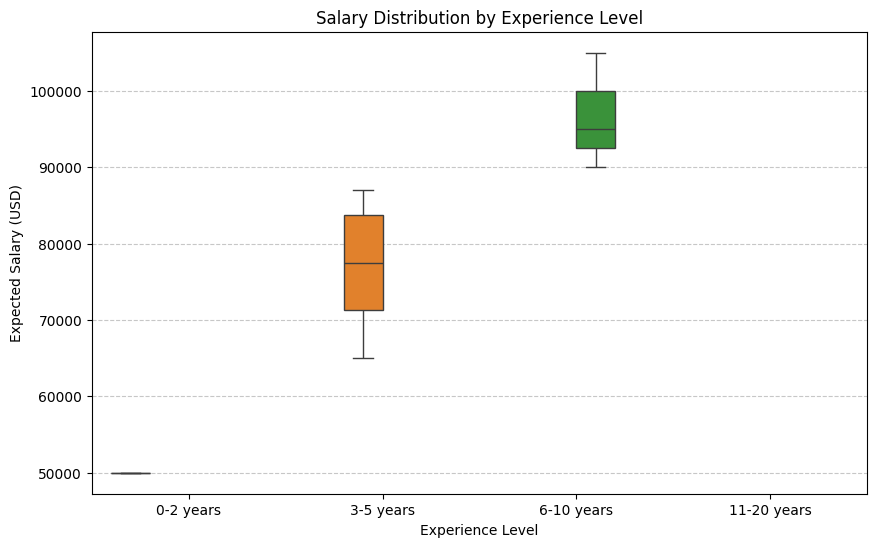

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = "C:/Users/Sharm/Downloads/candidate_list.csv" 
df = pd.read_csv(file_path)
bins = [0, 2, 5, 10, 20]  
labels = ["0-2 years", "3-5 years", "6-10 years", "11-20 years"]
df["Experience Category"] = pd.cut(df["Experience (Years)"], bins=bins, labels=labels, right=True)
plt.figure(figsize=(10, 6))
sns.boxplot(x="Experience Category", y="Expected Salary (USD)", hue="Experience Category", data=df, legend=False)
plt.xlabel("Experience Level")
plt.ylabel("Expected Salary (USD)")
plt.title("Salary Distribution by Experience Level")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()



In [ ]:
import pandas as pd
file_path =  "C:/Users/Sharm/Downloads/candidate_list.csv" 
df = pd.read_csv(file_path)
job_required_skills = {"Python", "Machine Learning", "SQL", "Data Science"}  
def skill_match(candidate_skills, job_skills):
    candidate_skills_set = set(candidate_skills.split(", "))  
    match_count = len(candidate_skills_set.intersection(job_skills))
    total_required = len(job_skills)


    return (match_count / total_required) * 100  # Percentage match
df["Skill Match (%)"] = df["Skills"].apply(lambda skills: skill_match(skills, job_required_skills))
qualified_candidates = df[df["Skill Match (%)"] >= 70]
filtered_file_path = "qualified_candidates.csv"


qualified_candidates.to_csv(filtered_file_path, index=False)
print(f"Filtered candidates saved as {filtered_file_path}")
print(qualified_candidates[["Candidate Name", "Skills", "Skill Match (%)"]])


Filtered candidates saved as qualified_candidates.csv
  Candidate Name                         Skills  Skill Match (%)
0  Alice Johnson  Python, SQL, Machine Learning             75.0


In [ ]:
import pandas as pd
file_path = "C:/Users/Sharm/Downloads/candidate_list.csv" 
df = pd.read_csv(file_path)
df["Skills"] = df["Skills"].fillna("").str.lower().str.split(", ")  # Convert to lowercase and split skills
job_skills = set(["python", "machine learning", "data analysis", "deep learning"])  #Example for job
def skill_match_percentage(candidate_skills, job_skills):
    candidate_skills_set = set(candidate_skills)
    intersection = len(candidate_skills_set.intersection(job_skills))
    match_percentage = (intersection / len(job_skills)) * 100 #Calculation
    return match_percentage
df["Skill Match %"] = df["Skills"].apply(lambda skills: skill_match_percentage(skills, job_skills))
qualified_candidates = df[df["Skill Match %"] >= 70]

#print the statement that candidates should match atleast 70%
print("Candidates Matching at least 70% of Required Skills:")
print(qualified_candidates[["Candidate Name", "Skills", "Skill Match %"]])

qualified_candidates.to_csv("filtered_candidates.csv", index=False)
print("Filtered candidates saved as 'filtered_candidates.csv'")


Candidates Matching at least 70% of Required Skills:
Empty DataFrame
Columns: [Candidate Name, Skills, Skill Match %]
Index: []
Filtered candidates saved as 'filtered_candidates.csv'


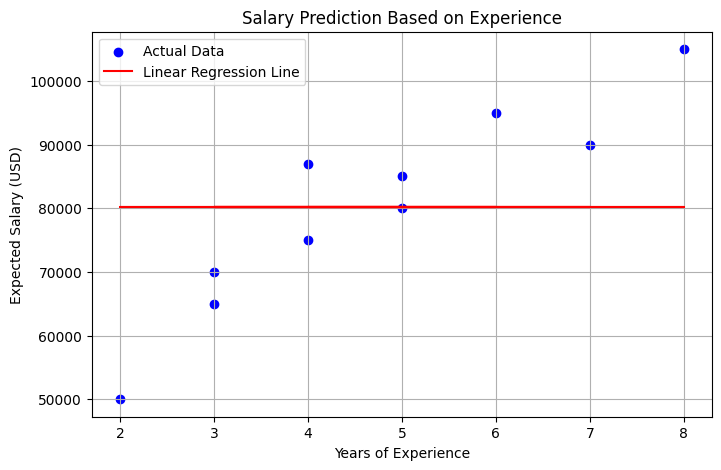

 Predicted Salary Formula: Salary = 0.00 * Experience + 80200.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = "C:/Users/Sharm/Downloads/candidate_list.csv"  
df = pd.read_csv(file_path)

df = df[["Experience (Years)", "Expected Salary (USD)"]].dropna()

X = df["Experience (Years)"].values.reshape(-1, 1)  
y = df["Expected Salary (USD)"].values  
n = len(X)
X_mean = np.mean(X)
y_mean = np.mean(y)

m = np.sum((X - X_mean) * (y - y_mean)) / np.sum((X - X_mean) ** 2)
b = y_mean - m * X_mean

def predict_salary(years):
    return m * years + b
df["Predicted Salary"] = df["Experience (Years)"].apply(predict_salary)
plt.figure(figsize=(8, 5))
plt.scatter(df["Experience (Years)"], df["Expected Salary (USD)"], color="blue", label="Actual Data")
plt.plot(df["Experience (Years)"], df["Predicted Salary"], color="red", label="Linear Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Expected Salary (USD)")
plt.title("Salary Prediction Based on Experience")
plt.legend()
plt.grid(True)
plt.show()

#Display formula
print(f" Predicted Salary Formula: Salary = {m:.2f} * Experience + {b:.2f}")


In [12]:
import pandas as pd
file_path = "C:/Users/Sharm/Downloads/candidate_list.csv"
df = pd.read_csv(file_path)
df["Skills"] = df["Skills"].fillna("").str.lower().str.split(", ") 
job_skills = set(["python", "machine learning", "data analysis", "deep learning"]) 

def jaccard_similarity(candidate_skills, job_skills):
    candidate_skills_set = set(candidate_skills) 
    intersection = len(candidate_skills_set.intersection(job_skills))
    union = len(candidate_skills_set.union(job_skills))
    return intersection / union if union != 0 else 0
df["Similarity Score"] = df["Skills"].apply(lambda skills: jaccard_similarity(skills, job_skills))
recommended_candidates = df.sort_values(by="Similarity Score", ascending=False).head(10)  
print("Recommended Candidates for the Job:")
print(recommended_candidates[["Candidate Name", "Skills", "Similarity Score"]])
recommended_candidates.to_csv("recommended_candidates.csv", index=False)
print("Recommendations saved as 'recommended_candidates.csv'")


Recommended Candidates for the Job:
  Candidate Name                              Skills  Similarity Score
0  Alice Johnson     [python, sql, machine learning]          0.400000
4  Emma Williams  [data science, python, tensorflow]          0.166667
9     Jack Davis            [ai, nlp, deep learning]          0.166667
1      Bob Smith  [java, spring boot, microservices]          0.000000
3      David Kim        [javascript, react, node.js]          0.000000
2    Charlie Lee        [c++, embedded systems, iot]          0.000000
5   Frank Miller  [html, css, javascript, bootstrap]          0.000000
6   Grace Turner      [cloud computing, aws, devops]          0.000000
7   Henry Wilson   [cybersecurity, network security]          0.000000
8      Ivy Brown         [django, flask, postgresql]          0.000000
Recommendations saved as 'recommended_candidates.csv'


In [13]:
import pandas as pd  

# Load dataset  
file_path = "C:/Users/Sharm/Downloads/sample_candidates_with_dates.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check if required columns exist
if "application_date" in df.columns and "job_offer_date" in df.columns:
    df["application_date"] = pd.to_datetime(df["application_date"], errors="coerce")
    df["job_offer_date"] = pd.to_datetime(df["job_offer_date"], errors="coerce")
    df["hiring_time_days"] = (df["job_offer_date"] - df["application_date"]).dt.days

    avg_hiring_time = df["hiring_time_days"].mean()
    hired_within_30 = df[df["hiring_time_days"] <= 30].shape[0]
    print(f"Avg Hiring Time: {avg_hiring_time:.2f} days | Hired ≤30 days: {hired_within_30}")





Avg Hiring Time: 12.00 days | Hired ≤30 days: 4


In [ ]:
import pandas as pd
file_path ="C:/Users/Sharm/Downloads/filtered_candidates.csv"  # Update the correct path
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["skills"] = df["skills"].fillna("").str.lower().str.split(", ")
job_skills = set(["python", "machine learning", "data analysis", "deep learning"])
def skill_match_percentage(candidate_skills, job_skills):
    candidate_skills_set = set(candidate_skills)
    intersection = len(candidate_skills_set.intersection(job_skills))
    match_percentage = (intersection / len(job_skills)) * 100
    return match_percentage
df["skill_match_%"] = df["skills"].apply(lambda skills: skill_match_percentage(skills, job_skills))
qualified_candidates = df[df["skill_match_%"] >= 70]
print("✅ Filtered Candidates (Matching ≥70% Skills):\n")
print(qualified_candidates[["name", "skills", "skill_match_%"]].to_string(index=False))  # Print without index


✅ Filtered Candidates (Matching ≥70% Skills):

Empty DataFrame
Columns: [name, skills, skill_match_%]
Index: []
